# Programação Linear — Otimização de uma Microrrede

## 1. Sistema considerado

Será considerada uma microrrede de **barra única**, composta pelos seguintes
componentes:

- **Bateria:** sistema de armazenamento de energia.
  - Capacidade de armazenamento;
  - Limite de carga;
  - Limite de descarga;
  - Estado inicial da bateria.

- **Painel solar:** sistema de geração fotovoltaica.
  - Capacidade instalada;
  - Perfil de geração de energia para cada hora.

- **Turbinas eólicas:** sistema de geração eólica.
  - Capacidade instalada;
  - Perfil de geração de energia para cada hora.

- **Geração termoelétrica a diesel:** fonte de geração convencional.
  - Capacidade máxima de geração por hora;
  - Preço do diesel;
  - Consumo de diesel ou custo associado à geração de energia.

- **Concessionária:** fornecimento externo de energia.
  - Preço da energia elétrica;
  - Limite de energia que pode ser adquirida, caso aplicável.

- **Carga:** demanda de energia da microrrede.
  - Demanda de energia para cada hora do dia.

## 2. Função objetivo

O problema será formulado como um problema de **Programação Linear**, tendo
como função objetivo a **minimização do custo total de operação da
microrrede**.

O custo será composto principalmente pelos custos associados à:

- geração de energia pelo sistema a diesel;
- compra de energia da concessionária.

Assim:

$$
\min Z =
C_{\mathrm{diesel}} +
C_{\mathrm{concessionária}}
$$

## 3. Variáveis de decisão

As principais variáveis de decisão do modelo serão:

- Energia utilizada para carregar a bateria;
- Energia fornecida pela bateria;
- Energia gerada pelo sistema a diesel;
- Energia comprada da concessionária;

## 4. Restrições

O modelo deverá respeitar as seguintes restrições:

### Balanço de potência ativa

Em cada hora, a energia fornecida pelas fontes, pela bateria e pela
concessionária deverá atender à demanda da carga, considerando também
eventual déficit.

### Bateria

O estado de carga da bateria deverá respeitar seus limites mínimo e máximo,
além dos limites de carga e descarga.

A evolução do estado de carga será determinada pela energia armazenada e pela
energia retirada da bateria em cada período.

Além disso, será considerada a condição:

$$
SOC_{\mathrm{final}} = SOC_{\mathrm{inicial}}
$$

### Limites de geração

A geração fotovoltaica, eólica e a diesel deverá respeitar os limites de
cada fonte e, no caso das fontes renováveis, a disponibilidade de geração
em cada hora.

### Compra de energia

A energia adquirida da concessionária deverá respeitar os limites
estabelecidos e seu custo será considerado na função objetivo.

## 5. Excedente de energia

Quando a geração renovável for superior à demanda da carga, o excedente
poderá ser utilizado para **carregar a bateria**, respeitando sua capacidade
e os limites de carga.

A decisão sobre o uso da bateria será determinada pelo modelo de otimização,
considerando os custos e as restrições estabelecidas.

Fontes: https://ieeexplore.ieee.org/document/7492611

https://www.sciencedirect.com/science/article/pii/S1364032115000696

In [ ]:
#Trabalho 1 - Métodos de Otimização

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo


In [ ]:
#Dados do problema

N_horas = 24

demanda_fixa = 345

caso = 1 #Define qual perfil de demanda será trabalhado: Demanda baixa -> caso = 0 / Demanda alta -> caso = 1
if caso == 0:
  P_demanda = [
      50, 50, 25, 0, 25, 25, 75, 175,
      275, 350, 375, 350, 325, 300, 300, 300,
      425, 525, 475, 400, 350, 275, 175, 125
  ]

  P_demanda += np.ones(N_horas)*demanda_fixa

if caso == 1:
  P_demanda = [
      200, 275, 250, 250, 275, 300, 450, 625,
      750, 900, 925, 825, 700, 825, 900, 800,
      925, 1000, 850, 700, 600, 600, 475, 300
  ]

  P_demanda += np.ones(N_horas)*demanda_fixa

if caso == 3:
  P_demanda = np.ones(N_horas)*1000

P_ger_sol = [0, 0, 0, 0, 0, 0, 0, 0, 150, 340, 650, 920, 560, 230, 80, 0, 0, 0, 0, 0, 0, 0, 0, 0]      #Potência gerada - geração solar
P_ger_eol = np.array([400, 400, 400, 325, 250, 525, 575, 550, 525, 500, 375, 400, 575,
             725, 1275, 1625, 2000, 1500, 750, 650, 325, 175, 150, 225])  #Potência gerada - geração eólica

#P_ger_eol[10] = 10

Cap_bat = 16*672                           #Capacidade da bateria (Wh)
SOC = np.empty(24)                         #Estado de carga da bateria
SOC_in = 0.6*Cap_bat                       #Estado de carga inicial da bateria
SOC_min = 0.5*Cap_bat*np.ones(N_horas)     #Estado mínimo de carga da bateria
SOC_max = 0.9*Cap_bat*np.ones(N_horas)     #Estado máximo de carga da bateria
Efic_car_bat = np.ones(N_horas)            #Eficiência de carga da bateria
Efic_desc_bat = np.ones(N_horas)           #Eficiência de descarga da bateria
lim_carga = 1000                           #Limite de carga da bateria
lim_descarga = 1000                        #Limite de descarga da bateria

custo_energia = np.ones(N_horas)
custo_energia[5:18] = 2*np.ones(13)
lim_compra = 1350
lim_venda = 1350


FOB = 2684.8


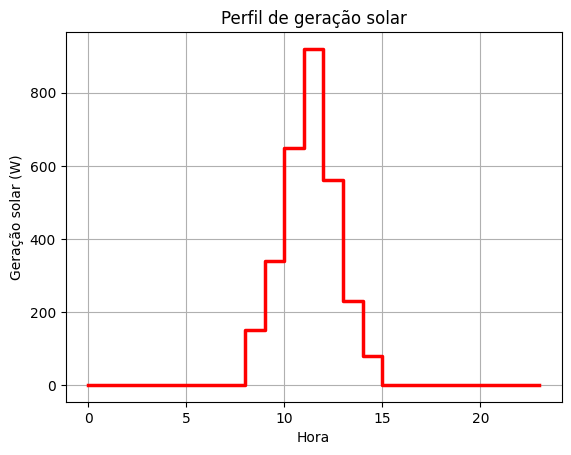

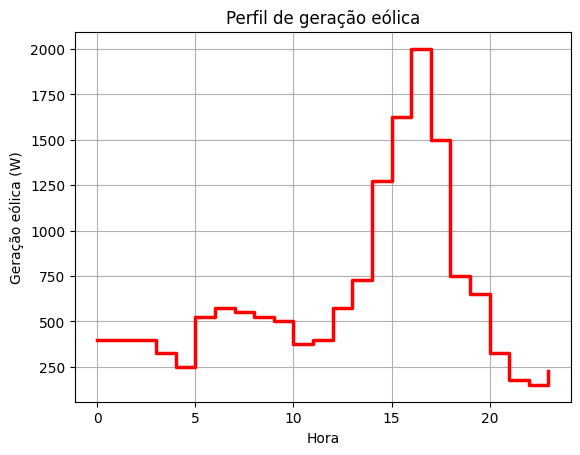

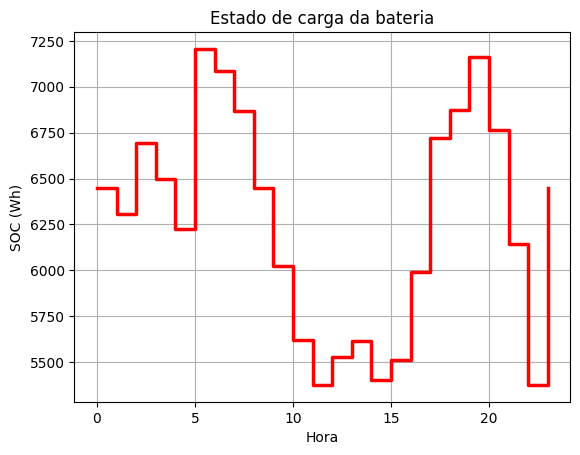

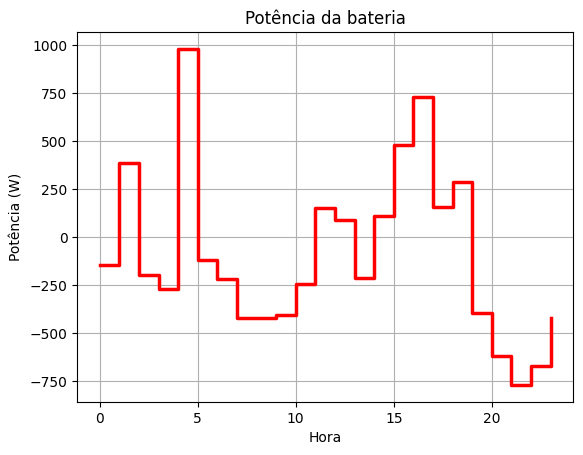

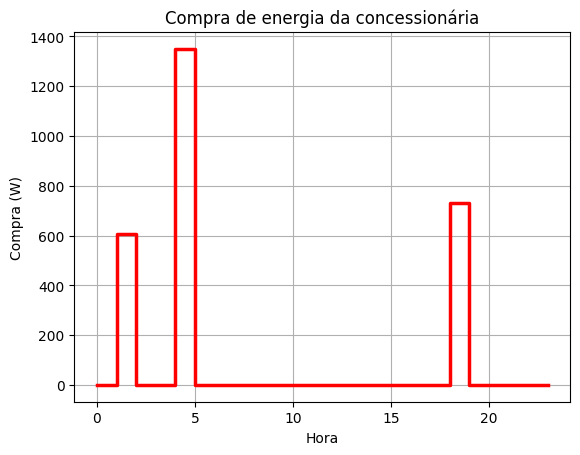

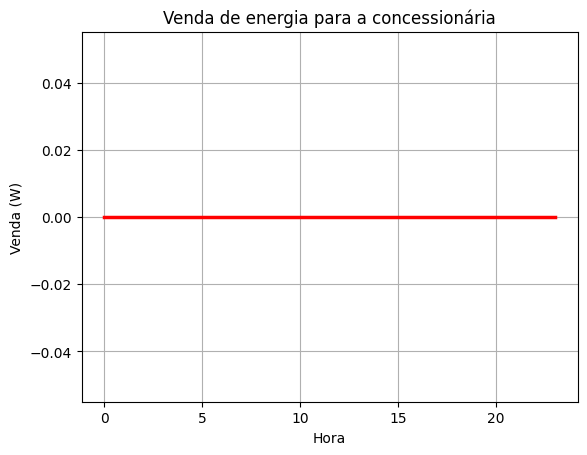

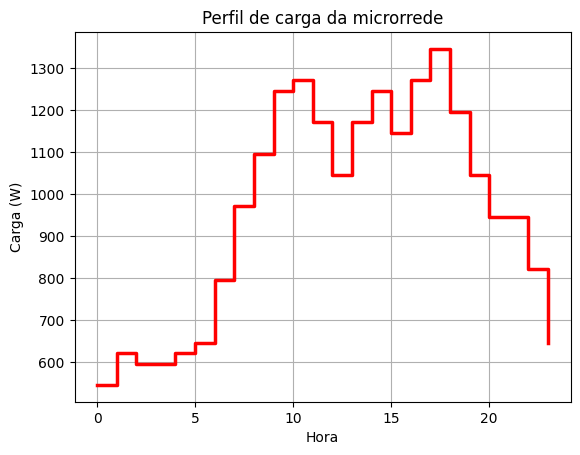

In [ ]:
#Criação do modelo---------------------------------------------------------------------------------------
model = pyo.ConcreteModel()

#Criação das variáveis
model.horas = pyo.RangeSet(0, N_horas - 1)
#model.horas.pprint()

model.carga_bat = pyo.Var(model.horas, domain = pyo.NonNegativeReals, bounds = (0, lim_carga))
model.descarga_bat = pyo.Var(model.horas, domain = pyo.NonNegativeReals, bounds = (0, lim_descarga))
#model.pot_bat = pyo.Var(model.horas, domain = pyo.NonNegativeReals)

model.compra = pyo.Var(model.horas, domain = pyo.NonNegativeReals,  bounds = (0, lim_compra))             #Energia comprada da concessionária
model.venda = pyo.Var(model.horas, domain = pyo.NonNegativeReals,  bounds = (0, lim_venda))

#model.ger_diesel = pyo.Var(model.horas, domain = pyo.NonNegativeReals)
#model.ger_mt = pyo.Var(model.horas, domain = pyo.NonNegativeReals)



#FOB-----------------------------------------------------------------------------------------------------
model.fob = pyo.Objective(expr = sum((model.compra[k]*custo_energia[k]) for k in model.horas),
                           sense = pyo.minimize)
#model.fob.pprint()


#Equações da bateria (carga e descarga)------------------------------------------------------------------
def soc_bat(model, h):
  if h == 0:
    return SOC_in
  elif h == 23:
    return SOC_in
  else:
    return (model.SOC_bat_exp[h-1] + model.carga_bat[h-1]*Efic_car_bat[h-1] -
            model.descarga_bat[h-1]*Efic_desc_bat[h-1])

model.SOC_bat_exp = pyo.Expression(model.horas, rule = soc_bat)

def lim_soc_bat(model,h):
  return pyo.inequality(SOC_min[h], model.SOC_bat_exp[h], SOC_max[h])

model.SOC_bat_lim = pyo.Constraint(model.horas, rule = lim_soc_bat)


#model.SOC_bat_exp.pprint()
#model.SOC_bat_lim.pprint()


#Limites da geração a diesel-------------------------------------------------------------------------------



#Balanço de potência ativa-------------------------------------------------------------------------------
def balanco_de_potencia(model, h):
    return (model.compra[h] - model.venda[h] + P_ger_eol[h] + P_ger_sol[h] +
            model.descarga_bat[h] == P_demanda[h] + model.carga_bat[h])

model.balanco_potencia = pyo.Constraint(model.horas, rule = balanco_de_potencia)
#model.balanco_potencia.pprint()



#Início do processo ed otimização------------------------------------------------------------------------
solver = pyo.SolverFactory("highs")

resultado = solver.solve(model)


#Resultados----------------------------------------------------------------------------------------------

print("FOB =", pyo.value(model.fob))

horas = list(model.horas)

plt.step(horas, P_ger_sol, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("Geração solar (W)")
plt.title("Perfil de geração solar")
plt.grid()
plt.show()


plt.step(horas, P_ger_eol, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("Geração eólica (W)")
plt.title("Perfil de geração eólica")
plt.grid()
plt.show()

soc = [
    pyo.value(model.SOC_bat_exp[h])
    for h in model.horas
]

plt.step(horas, soc, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("SOC (Wh)")
plt.title("Estado de carga da bateria")
plt.grid()
plt.show()

carga = np.array([
    pyo.value(model.carga_bat[h])
    for h in model.horas
])

descarga = np.array([
    pyo.value(model.descarga_bat[h])
    for h in model.horas
])

bateria = carga - descarga

plt.step(horas, bateria, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("Potência (W)")
plt.title("Potência da bateria")
plt.grid()
plt.show()


compra = [
    pyo.value(model.compra[h])
    for h in model.horas
]

venda = [
    pyo.value(model.venda[h])
    for h in model.horas
]

plt.step(horas, compra, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("Compra (W)")
plt.title("Compra de energia da concessionária")
plt.grid()
plt.show()


plt.step(horas, venda, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("Venda (W)")
plt.title("Venda de energia para a concessionária")
plt.grid()
plt.show()


plt.step(horas, P_demanda, where='post', color ='red', linewidth=2.5)
plt.xlabel("Hora")
plt.ylabel("Carga (W)")
plt.title("Perfil de carga da microrrede")
plt.grid()
plt.show()
